# 01 · Exploratory Data Analysis

**Dataset:** 2026 Car Fuel Efficiency (`data/car_fuel_efficiency_2026.csv`)
**Goal:** predict `fuel_efficiency_mpg` from vehicle specifications.

This notebook only *looks* at the data. Column selection, imputation and splitting live in
`02_data_transformation.ipynb`; model training lives in `03_training_and_analysis.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

df = pd.read_csv("../data/car_fuel_efficiency_2026.csv")
df.shape

(10000, 11)

## 1. Structure

In [2]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.000,3870,NaN,31.900
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.000,4210,NaN,31.300
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.000,4240,17.300,27.500
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.000,4490,18.700,28.500
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.000,4510,17.500,31.000


In [3]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,10000.000,1999.550,14.208,1975.000,1987.000,2000.000,2012.000,2024.000
num_doors,10000.000,3.504,0.952,2.000,3.000,4.000,4.000,5.000
engine_displacement,10000.000,2268.807,183.447,1590.000,2150.000,2270.000,2390.000,3110.000
num_cylinders,10000.000,6.035,0.543,4.000,6.000,6.000,6.000,8.000
horsepower,9123.000,254.446,22.845,171.000,239.000,254.000,270.000,334.000
vehicle_weight,10000.000,4286.754,266.212,3320.000,4110.000,4280.000,4470.000,5460.000
acceleration,9736.000,18.888,1.280,14.000,18.000,18.900,19.700,23.800
fuel_efficiency_mpg,10000.000,29.998,2.930,19.800,28.000,30.000,31.900,41.200


## 2. Missing values

In [5]:
missing = df.isna().sum().to_frame("missing")
missing["pct"] = missing["missing"] / len(df) * 100
missing[missing["missing"] > 0]

,missing,pct
horsepower,877,8.770
acceleration,264,2.640


Two columns have gaps: `horsepower` (~8.8 %) and `acceleration` (~2.6 %). `acceleration` is not used in
the homework, so `horsepower` is the only column that needs handling.

## 3. Target: `fuel_efficiency_mpg`

In [6]:
y = df["fuel_efficiency_mpg"]
print(y.describe())
print(f"\nskewness: {y.skew():.3f}")
print(f"mean - median: {y.mean() - y.median():.3f}")
print(y.quantile([0.01, 0.05, 0.5, 0.95, 0.99]))

count   10000.000
mean       29.998
std         2.930
min        19.800
25%        28.000
50%        30.000
75%        31.900
max        41.200
Name: fuel_efficiency_mpg, dtype: float64

skewness: 0.081
mean - median: -0.002
0.010   23.300
0.050   25.200
0.500   30.000
0.950   34.905
0.990   36.900
Name: fuel_efficiency_mpg, dtype: float64


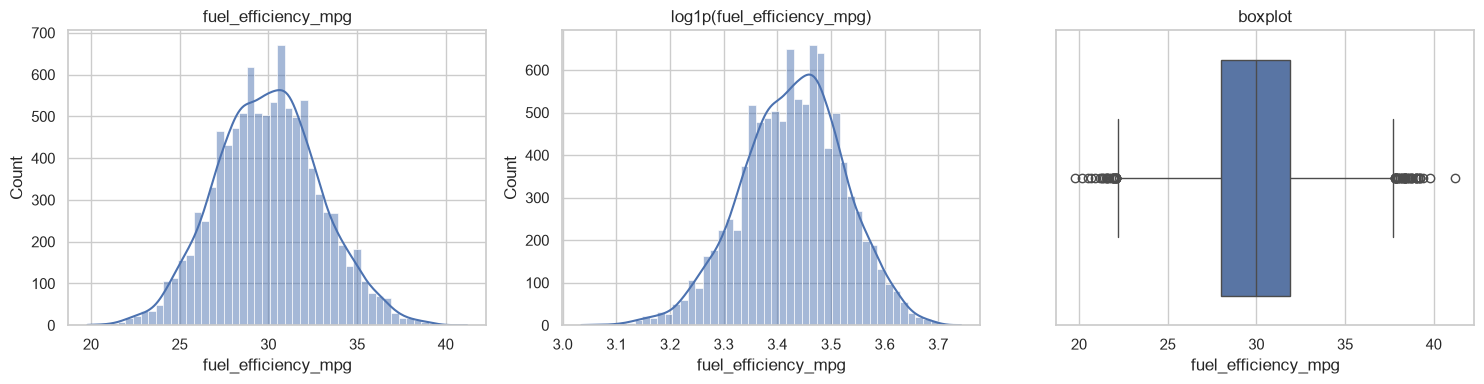

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(y, bins=50, kde=True, ax=axes[0])
axes[0].set_title("fuel_efficiency_mpg")
sns.histplot(np.log1p(y), bins=50, kde=True, ax=axes[1])
axes[1].set_title("log1p(fuel_efficiency_mpg)")
sns.boxplot(x=y, ax=axes[2])
axes[2].set_title("boxplot")
plt.tight_layout()
plt.show()

**Does the target have a long tail? No.**
The distribution is symmetric and bell-shaped: skewness ≈ 0.08, mean ≈ median (30.0), and the min/max
(19.8 / 41.2) sit roughly the same distance from the centre. There is no long right tail, so a log
transform of the target is *not* needed here (unlike price-style targets).

## 4. Features

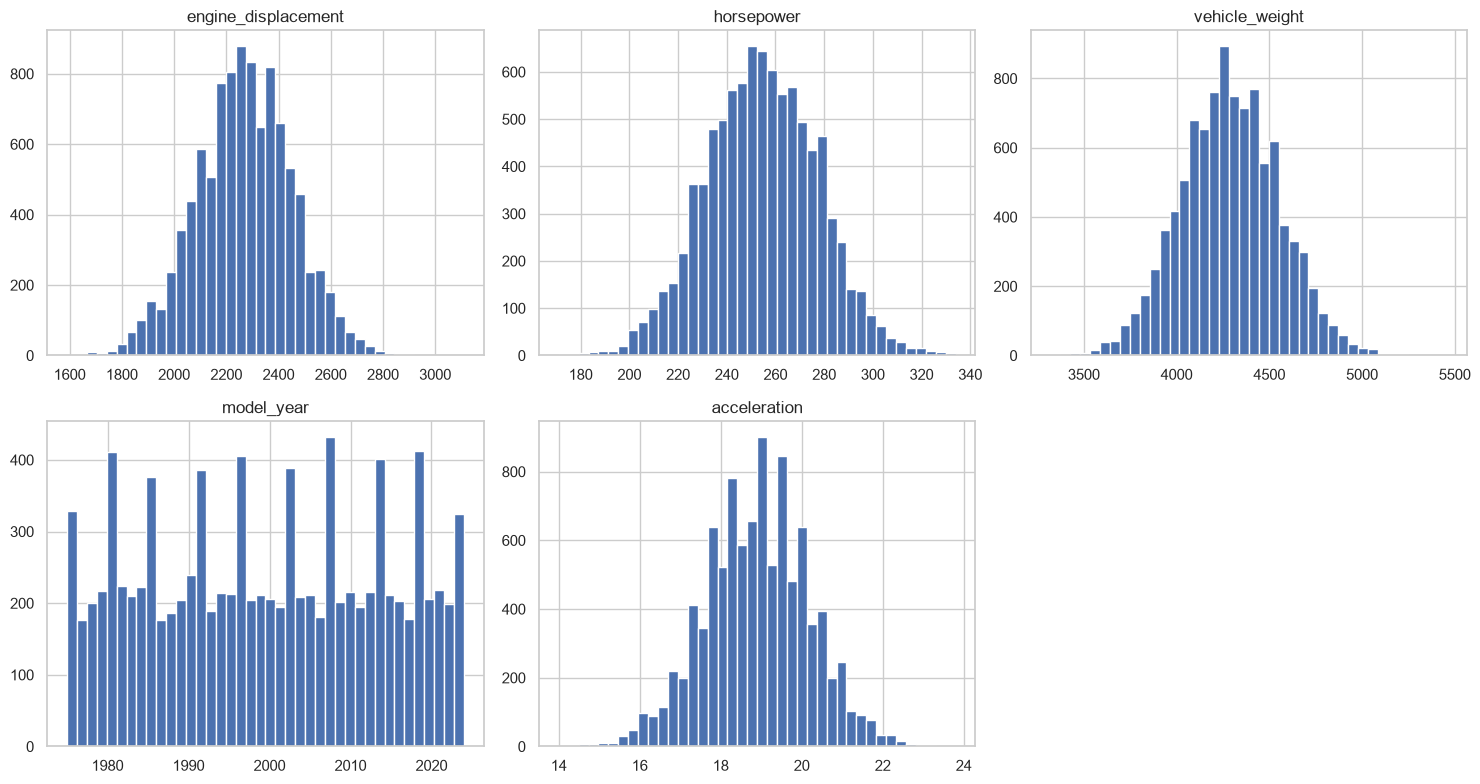

In [8]:
num_cols = ["engine_displacement", "horsepower", "vehicle_weight", "model_year", "acceleration"]
df[num_cols].hist(bins=40, figsize=(15, 8), layout=(2, 3))
plt.tight_layout()
plt.show()

## 5. Relationships with the target

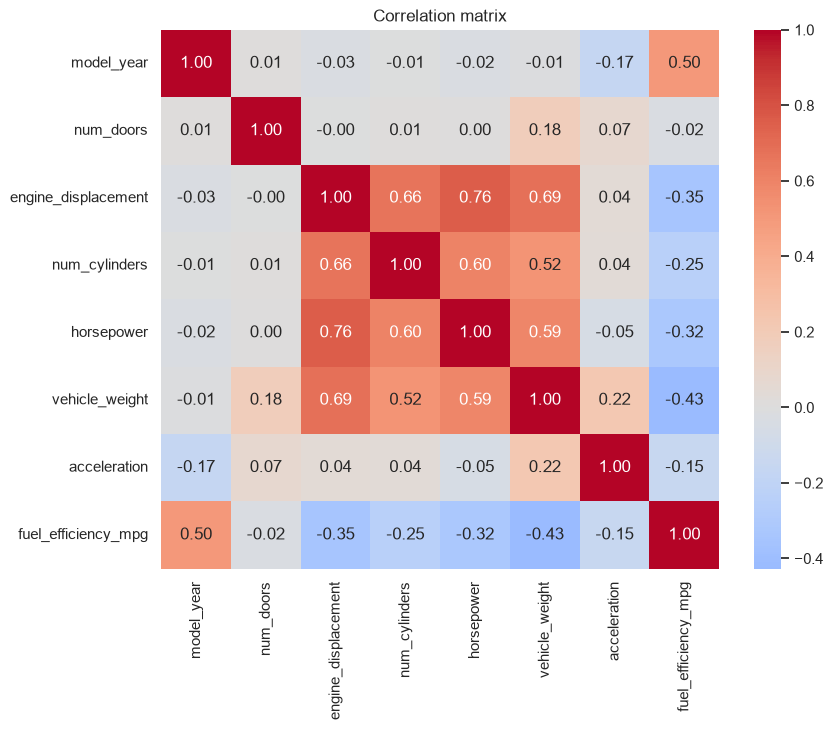

model_year             0.500
vehicle_weight        -0.427
engine_displacement   -0.348
horsepower            -0.321
num_cylinders         -0.247
acceleration          -0.150
num_doors             -0.021
Name: fuel_efficiency_mpg, dtype: float64

In [9]:
corr = df.select_dtypes("number").corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

corr["fuel_efficiency_mpg"].drop("fuel_efficiency_mpg").sort_values(key=abs, ascending=False)

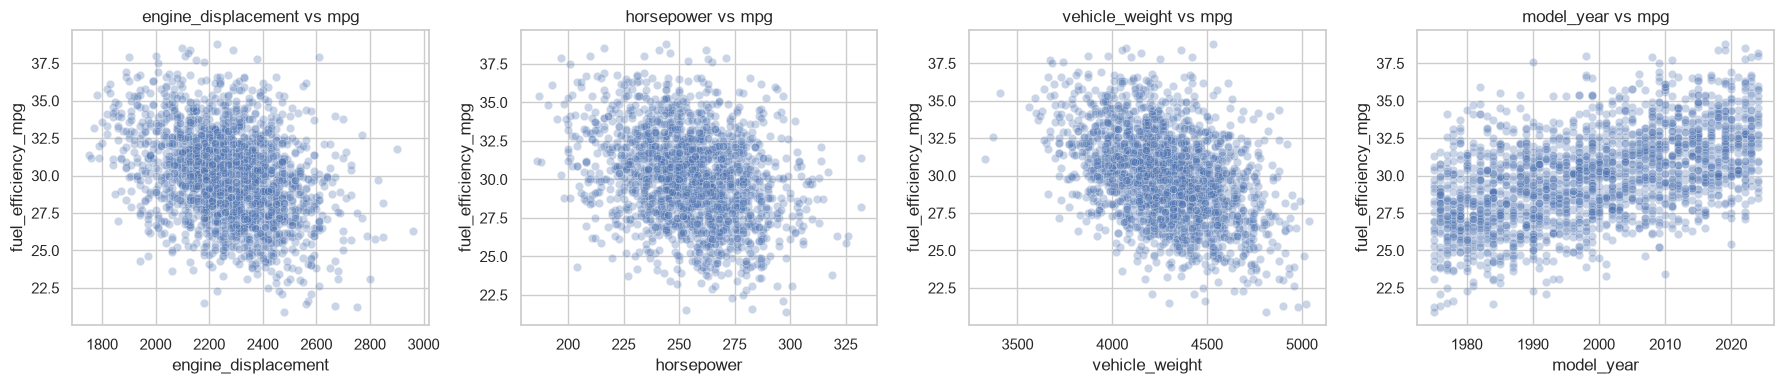

In [10]:
feats = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, feats):
    sns.scatterplot(data=df.sample(2000, random_state=42), x=c, y="fuel_efficiency_mpg", alpha=0.3, ax=ax)
    ax.set_title(f"{c} vs mpg")
plt.tight_layout()
plt.show()

## 6. Categorical columns (not used in the homework, kept for reference)

In [11]:
cat_cols = ["origin", "fuel_type", "drivetrain", "num_doors", "num_cylinders"]
for c in cat_cols:
    print(df.groupby(c)["fuel_efficiency_mpg"].agg(["count", "mean", "std"]), "\n")

        count   mean   std
origin                    
Asia     2994 30.741 2.835
Europe   2804 30.553 2.791
USA      4202 29.098 2.847 

           count   mean   std
fuel_type                    
Diesel      2053 31.029 2.627
Gasoline    6913 29.214 2.636
Hybrid      1034 33.191 2.544 

                   count   mean   std
drivetrain                           
All-wheel drive     2026 28.865 2.841
Front-wheel drive   5519 30.670 2.802
Rear-wheel drive    2455 29.422 2.874 

           count   mean   std
num_doors                    
2           1647 30.161 2.937
3           3301 29.981 2.885
4           3417 29.966 2.954
5           1635 29.933 2.960 

               count   mean   std
num_cylinders                    
4                  2 35.550 5.020
5               1286 31.354 2.768
6               7080 30.050 2.849
7               1622 28.709 2.851
8                 10 26.210 2.722 



## Takeaways

* 10 000 rows, 11 columns; only `horsepower` (877) and `acceleration` (264) have missing values.
* Target is roughly normal (no long tail) — no target transform required.
* `model_year` (+0.50) is the strongest correlate of mpg, followed by `vehicle_weight` (-0.43),
  `engine_displacement` (-0.35) and `horsepower` (-0.32). The three engine/size features are correlated
  with each other (displacement-horsepower 0.76), so expect overlapping signal in a linear model.
* Next: `02_data_transformation.ipynb`.